# Direct Preference Optimization (DPO) Analysis

$$\mathcal{L}_{\text{DPO}}(\pi_\theta; \pi_{\text{ref}}) = -\mathbb{E}_{(x, a^{+}, a^{-}) \sim \mathcal{D}} \left[ \log \sigma \left( \beta \log \frac{\pi_\theta(a^{+} \mid x)}{\pi_{\text{ref}}(a^{+} \mid x)} - \beta \log \frac{\pi_\theta(a^{-} \mid x)}{\pi_{\text{ref}}(a^{-} \mid x)} \right) \right]$$

We need:
1. A **policy model** $\pi_\theta$
2. A frozen **reference model** $\pi_{\text{ref}}$
3. The **DPO loss function**
4. A **training loop** that handles both models

#### Run this ONLY if you're inside Google Collab

In [1]:
!apt-get -qq update
!apt-get -qq install -y ffmpeg

from google.colab import drive  # type: ignore
drive.mount('/content/drive')


!git clone https://github.com/pedropintoo/RL-project.git /content/RL-project

!pip install stable_baselines3

%cd /content/RL-project/dpo
!git stash
!git pull --ff-only origin main

import sys
sys.path.append("/content/RL-project/dpo")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Failed to fetch https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu/dists/jammy/InRelease  503  Service Unavailable [IP: 185.125.190.80 443]
W: Failed to fetch https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu/dists/jammy/main/binary-amd64/Packages  503  Service Unavailable [IP: 185.125.190.80 443]
W: Some index files failed to download. They have been ignored, or old ones used instead.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path '/content/RL-project' already exists and is not an empty directory.
/content/RL-project/dpo
No local changes to save
From https://github.com/pedropintoo/RL-project
 * branch            main       -> FETCH_HEAD
Already up to date.


### Import the Necessary Packages

In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from collections import deque
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import copy
import os
import sys
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

from stable_baselines3 import PPO

from pathlib import Path

from utils import load_preference_dataset, preference_pair_logps, show_video_of_model, show_video, evaluate_policy_returns

from policy import DiscretePolicy, ContinuousPolicy, SB3DiscretePolicyAdapter, SB3ContinuousPolicyAdapter

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### The DPO Loss Function

$$\mathcal{L}_{\text{DPO}} = -\log \sigma\left( \beta \cdot \left[ \left(\log \pi_\theta(a^{+}|x) - \log \pi_{\text{ref}}(a^{+}|x)\right) - \left(\log \pi_\theta(a^{-}|x) - \log \pi_{\text{ref}}(a^{-}|x)\right) \right] \right)$$

In [4]:
from dpo_experiments import run_dpo_scaling_experiment
from dpo_plotting import plot_environment_results
from config import ENVIRONMENTS


### Scaling Experiment (Modular Version)

This section mirrors the RLHF protocol:

- Dataset sizes: $K \in \{50, 200, 1000\}$
- Seeds: $\{1,2,3,4,5\}$
- Train one DPO model per $(K, \text{seed})$
- Aggregate return statistics across seeds
- Plot scaling curves with the same style used in `rlhf/plot_results.py`

In [13]:
K_VALUES = [50, 200, 1000]
SEEDS = [1, 2, 3, 4, 5]
ENV_IDS = [cfg.env_id for cfg in ENVIRONMENTS]

PREFERENCE_DIR = Path("../data_generation/outputs/preferences")
POLICY_DIR = Path("../data_generation/outputs/policies")

# Persistent output directory (Google Drive in Colab)
DPO_OUTPUT_DIR = Path('/content/drive/MyDrive/RL-project/outputs/dpo_scaling')
print(f"DPO output directory: {DPO_OUTPUT_DIR}")

PLOT_DIR = DPO_OUTPUT_DIR / "plots"

DPO_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Main sweep hyperparameters
N_EPOCHS = 200
LEARNING_RATE = 1e-4
BETA = 0.1
PLATEAU_WINDOW = 12
N_EVAL_EPISODES = 50

DPO output directory: /content/drive/MyDrive/RL-project/outputs/dpo_scaling



### Load Preference Dataset

$$(x, a^{+}, a^{-}) \sim \mathcal{D}$$

In [14]:
all_results = {}

for env_id in ENV_IDS:
    print(f"\n================ {env_id} ================")
    env_results = run_dpo_scaling_experiment(
        env_id=env_id,
        dataset_sizes=K_VALUES,
        seeds=SEEDS,
        preference_dir=PREFERENCE_DIR,
        policy_dir=POLICY_DIR,
        output_dir=DPO_OUTPUT_DIR,
        device=device,
        n_epochs=N_EPOCHS,
        lr=LEARNING_RATE,
        beta=BETA,
        early_stop=True,
        plateau_window=PLATEAU_WINDOW,
        n_eval_episodes=N_EVAL_EPISODES,
    )
    all_results.update(env_results)

results_file = DPO_OUTPUT_DIR / "dpo_scaling_all_envs.json"
with results_file.open("w", encoding="utf-8") as f:
    json.dump(all_results, f, indent=2)

print(f"\nSaved merged results to {results_file}")


================ CartPole-v1 ================
Evaluating baselines for CartPole-v1...

=== DPO | env=CartPole-v1 | K=50 ===
Training DPO for K=50, seed=1...
Epoch 1	Average Loss: 0.55954911	Best: 0.55954911 (epoch 1)
Restored best checkpoint from epoch 1 with loss 0.5595.
Training DPO for K=50, seed=2...
Epoch 1	Average Loss: 0.55754592	Best: 0.55754592 (epoch 1)
Restored best checkpoint from epoch 1 with loss 0.5575.
Training DPO for K=50, seed=3...
Epoch 1	Average Loss: 0.55917094	Best: 0.55917094 (epoch 1)
Restored best checkpoint from epoch 1 with loss 0.5592.
Training DPO for K=50, seed=4...
Epoch 1	Average Loss: 0.55873281	Best: 0.55873281 (epoch 1)
Restored best checkpoint from epoch 1 with loss 0.5587.
Training DPO for K=50, seed=5...
Epoch 1	Average Loss: 0.55734504	Best: 0.55734504 (epoch 1)
Restored best checkpoint from epoch 1 with loss 0.5573.

=== DPO | env=CartPole-v1 | K=200 ===
Training DPO for K=200, seed=1...
Epoch 1	Average Loss: 0.25753962	Best: 0.25753962 (epoch 

### Policy Model + Reference Model

In [7]:
import pandas as pd

rows = []
for env_id, env_data in all_results.items():
    rows.append({
        "env": env_id,
        "method": "expert",
        "K": "-",
        "mean": env_data["baselines"]["expert"]["mean"],
        "std": env_data["baselines"]["expert"]["std"],
    })
    rows.append({
        "env": env_id,
        "method": "mid",
        "K": "-",
        "mean": env_data["baselines"]["mid"]["mean"],
        "std": env_data["baselines"]["mid"]["std"],
    })

    for k in sorted(env_data["dpo"].keys(), key=int):
        rows.append({
            "env": env_id,
            "method": "dpo",
            "K": int(k),
            "mean": env_data["dpo"][k]["mean"],
            "std": env_data["dpo"][k]["std"],
        })

summary_df = pd.DataFrame(rows).sort_values(["env", "method", "K"], na_position="last")
summary_df

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,env,method,K,mean,std
2,CartPole-v1,dpo,50,87.564000,3.058925
3,CartPole-v1,dpo,200,89.880000,3.217403
4,CartPole-v1,dpo,1000,110.832000,3.649605
0,CartPole-v1,expert,-,500.000000,0.000000
1,CartPole-v1,mid,-,336.620000,200.303958
7,Pendulum-v1,dpo,50,-869.347618,30.864832
8,Pendulum-v1,dpo,200,-1069.776538,49.945277
9,Pendulum-v1,dpo,1000,-1123.152558,11.570977
5,Pendulum-v1,expert,-,-275.359714,294.574813
6,Pendulum-v1,mid,-,-668.018614,126.032294


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

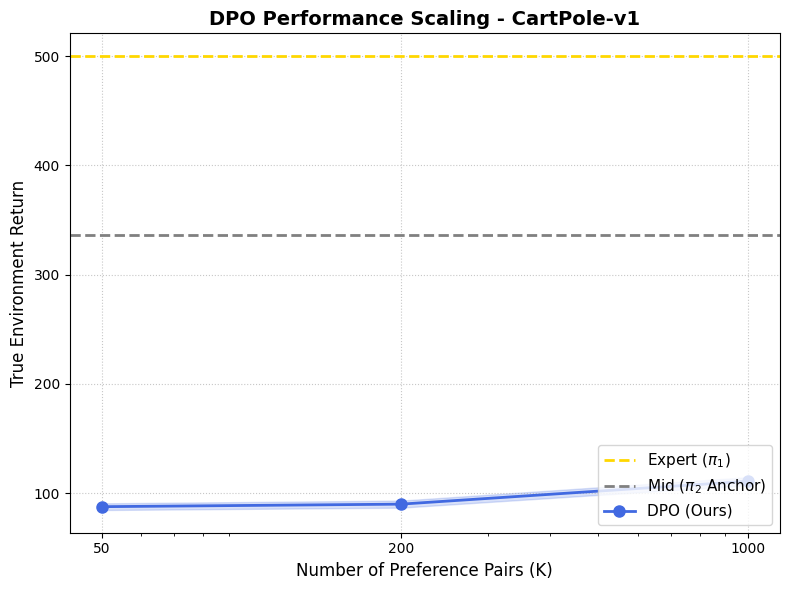

Saved plot to outputs/dpo_scaling/plots/CartPole-v1_scaling_plot.png


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


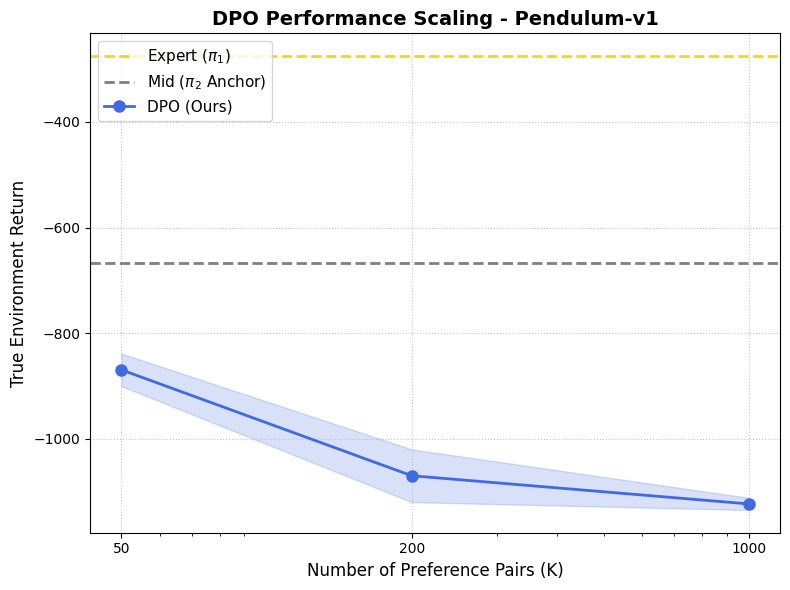

Saved plot to outputs/dpo_scaling/plots/Pendulum-v1_scaling_plot.png


In [8]:
for env_id, env_data in all_results.items():
    plot_path = plot_environment_results(env_id, env_data, PLOT_DIR)
    print(f"Saved plot to {plot_path}")

In [9]:
for env_id, env_data in all_results.items():
    print(f"\n{env_id} raw returns by K and seed:")
    for k in sorted(env_data["dpo"].keys(), key=int):
        print(f"  K={k}: {env_data['dpo'][k]['raw_seeds']}")


CartPole-v1 raw returns by K and seed:
  K=50: [87.76, 85.68, 93.34, 86.38, 84.66]
  K=200: [91.8, 95.1, 85.94, 88.58, 87.98]
  K=1000: [116.34, 109.82, 112.46, 110.4, 105.14]

Pendulum-v1 raw returns by K and seed:
  K=50: [-899.7290200536492, -842.9954571553078, -827.2703148664372, -870.3245380410398, -906.4187595392448]
  K=200: [-1108.1510252557662, -1083.9946957484635, -1056.9146328085264, -1120.0652896771605, -979.7570448988617]
  K=1000: [-1133.964780122798, -1132.0759909341684, -1119.11221189217, -1102.3934754653328, -1128.2163317092338]


In [10]:
np.bool8 = np.bool
save_path = './demos/'
Path(save_path).mkdir(parents=True, exist_ok=True)
names = ['p_expert', 'p_mid', 'policy_model']

for i, policy in enumerate([p_expert, p_mid, policy_model]):
    file = save_path + names[i]
    print(f"Showing video for {names[i]}...")
    # create video
    show_video_of_model(file, policy, 'Pendulum-v1')

    # show video
    show_video(file, 'Pendulum-v1')

NameError: name 'p_expert' is not defined

In [ ]:
# Optional: export summary table
summary_csv = DPO_OUTPUT_DIR / "dpo_scaling_summary.csv"
summary_df.to_csv(summary_csv, index=False)
print(f"Saved table to {summary_csv}")